In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
loan_approval_data = pd.read_csv("loan_approval_data.csv")

In [3]:
loan_approval_data.head()
loan_approval_data.info()
loan_approval_data.isnull().sum
loan_approval_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


In [4]:
#HANDLE MISSING VALUES

In [5]:
categorical_columns = loan_approval_data.select_dtypes(include=["object"]).columns
numerical_columns = loan_approval_data.select_dtypes(include=["float64"]).columns

In [6]:
categorical_columns

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')

In [7]:
numerical_columns

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='object')

In [8]:
categorical_columns.size+numerical_columns.size

20

In [9]:
from sklearn.impute import SimpleImputer
num_imp = SimpleImputer(strategy = "mean")
loan_approval_data[numerical_columns]=num_imp.fit_transform(loan_approval_data[numerical_columns])

In [10]:
loan_approval_data.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [11]:
cat_imp = SimpleImputer(strategy = "most_frequent")
loan_approval_data[categorical_columns]=cat_imp.fit_transform(loan_approval_data[categorical_columns])

In [12]:
loan_approval_data.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

#Exploratory Data Analysis

Text(0.5, 1.0, 'is loan approved or not')

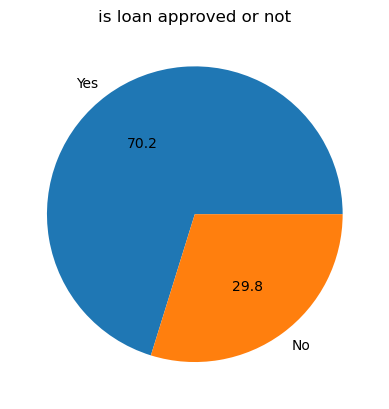

In [13]:
classes_count = loan_approval_data["Loan_Approved"].value_counts()
plt.pie(classes_count, labels = ["Yes", "No"], autopct = "%1.1f")
plt.title("is loan approved or not")

[Text(0, 0, '621'), Text(0, 0, '379')]

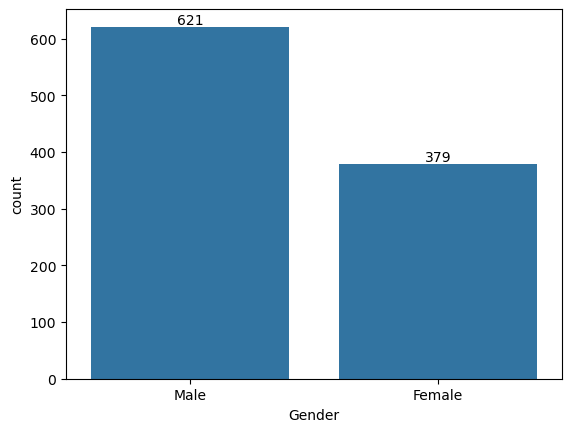

In [14]:
gender_count = loan_approval_data["Gender"].value_counts()
ax = sns.barplot(gender_count)
ax.bar_label(ax.containers[0])

[Text(0, 0, '722'), Text(0, 0, '278')]

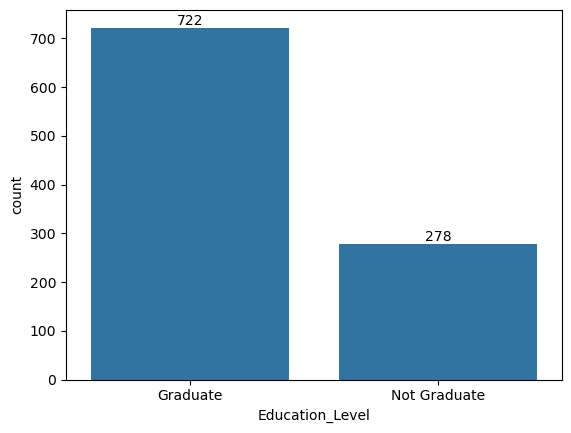

In [15]:
education_level = loan_approval_data["Education_Level"].value_counts()
ax = sns.barplot(education_level)
ax.bar_label(ax.containers[0])

[Text(0, 0, '422'),
 Text(0, 0, '202'),
 Text(0, 0, '144'),
 Text(0, 0, '135'),
 Text(0, 0, '97')]

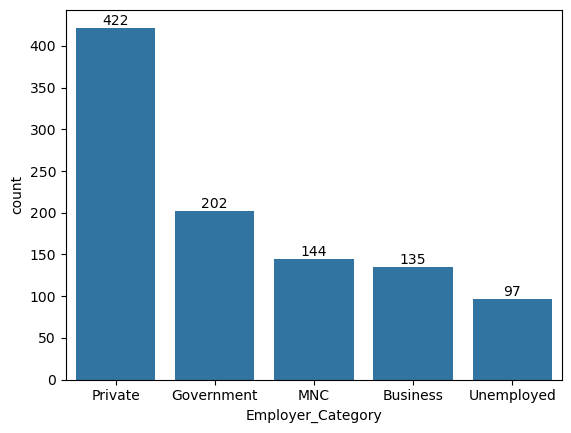

In [16]:
education_level = loan_approval_data["Employer_Category"].value_counts()
ax = sns.barplot(education_level)
ax.bar_label(ax.containers[0])

[Text(0, 0, '517'), Text(0, 0, '294'), Text(0, 0, '189')]

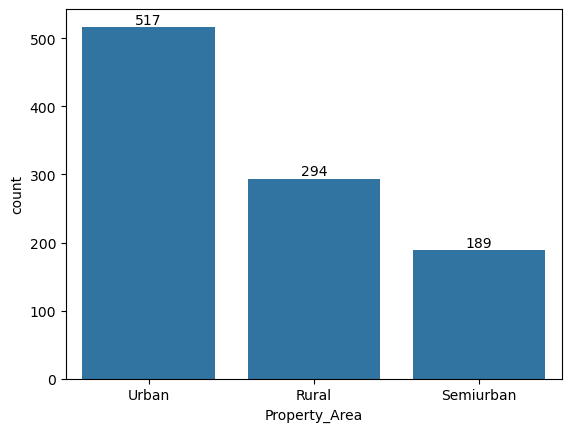

In [17]:
education_level = loan_approval_data["Property_Area"].value_counts()
ax = sns.barplot(education_level)
ax.bar_label(ax.containers[0])

[Text(0, 0, '643'), Text(0, 0, '357')]

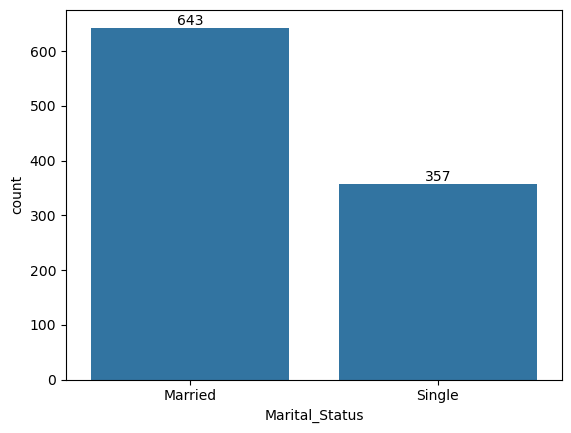

In [18]:
education_level = loan_approval_data["Marital_Status"].value_counts()
ax = sns.barplot(education_level)
ax.bar_label(ax.containers[0])

[Text(0, 0, '230'),
 Text(0, 0, '270'),
 Text(0, 0, '50'),
 Text(0, 0, '219'),
 Text(0, 0, '231')]

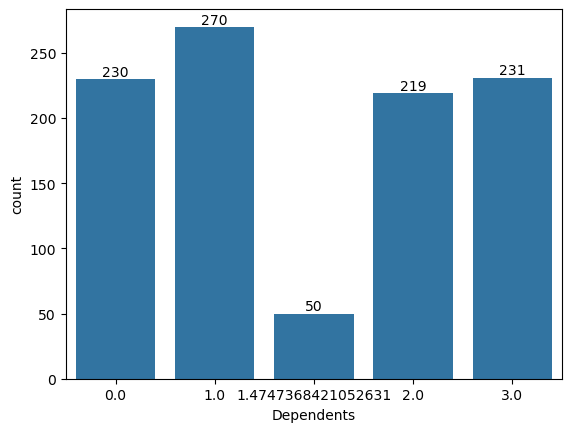

In [19]:
education_level = loan_approval_data["Dependents"].value_counts()
ax = sns.barplot(education_level)
ax.bar_label(ax.containers[0])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

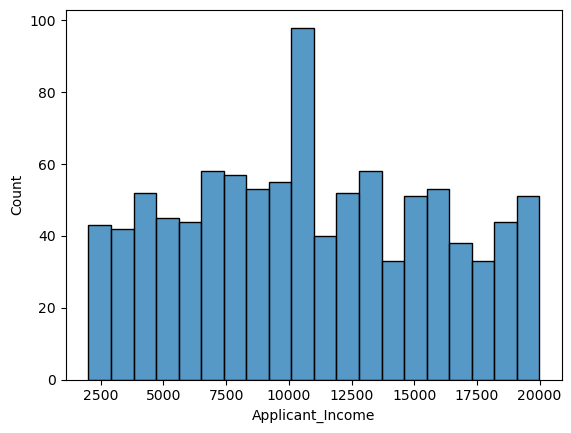

In [20]:
sns.histplot(
     data=loan_approval_data,
    x="Applicant_Income",
    bins=20
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

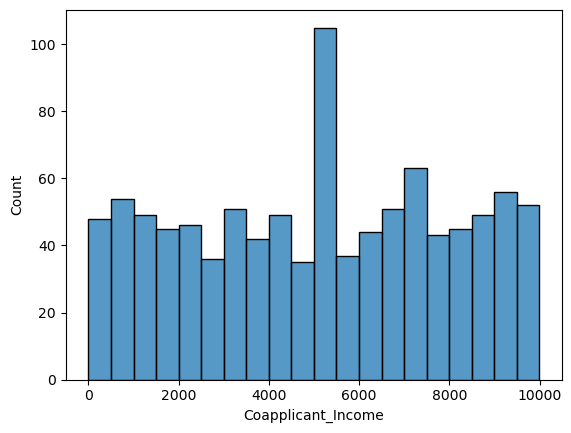

In [21]:
sns.histplot(
     data=loan_approval_data,
    x="Coapplicant_Income",
    bins=20
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

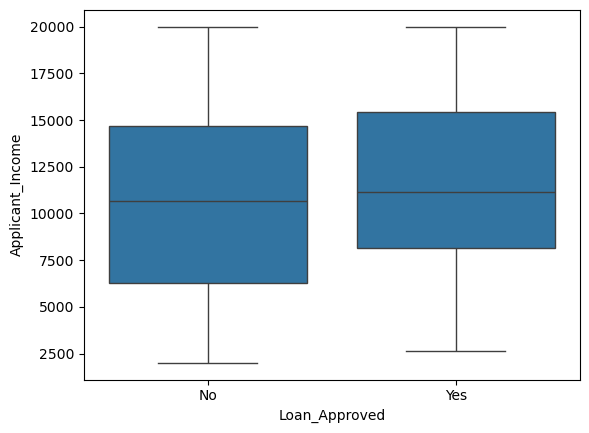

In [22]:
#outliers(boxplot)
sns.boxplot(
    data=loan_approval_data,
    y="Applicant_Income",
    x = "Loan_Approved"
)

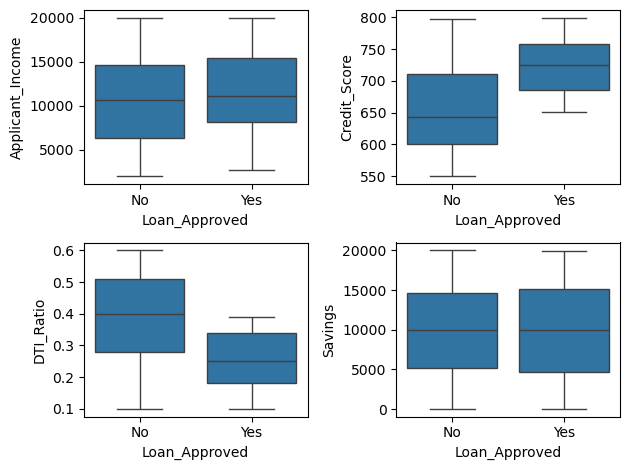

In [23]:
fig, axes = plt.subplots(2,2)
sns.boxplot(ax=axes[0, 0 ],data=loan_approval_data,y="Applicant_Income",x = "Loan_Approved")
sns.boxplot(ax=axes[0, 1 ],data=loan_approval_data,y="Credit_Score",x = "Loan_Approved")
sns.boxplot(ax=axes[1, 0 ],data=loan_approval_data,y="DTI_Ratio",x = "Loan_Approved")
sns.boxplot(ax=axes[1, 1 ],data=loan_approval_data,y="Savings",x = "Loan_Approved")
plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

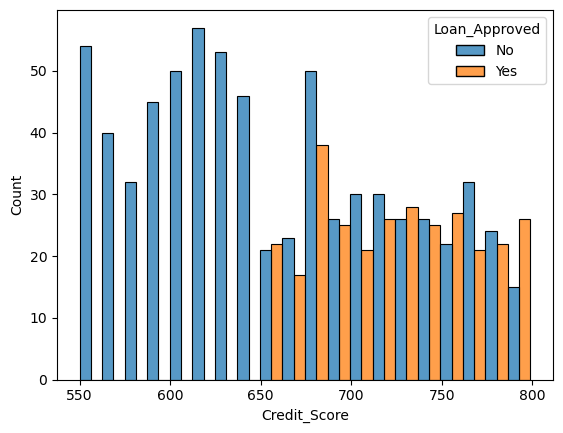

In [24]:
sns.histplot(
    data=loan_approval_data,
    x="Credit_Score",
    hue = "Loan_Approved",
    bins = 20,
    multiple ="dodge"
)


In [25]:
loan_approval_data = loan_approval_data.drop("Applicant_ID", axis = 1)

In [26]:
loan_approval_data.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


In [27]:
#applicant id is not important for our model
loan_approval_data.columns

Index(['Applicant_Income', 'Coapplicant_Income', 'Employment_Status', 'Age',
       'Marital_Status', 'Dependents', 'Credit_Score', 'Existing_Loans',
       'DTI_Ratio', 'Savings', 'Collateral_Value', 'Loan_Amount', 'Loan_Term',
       'Loan_Purpose', 'Property_Area', 'Education_Level', 'Gender',
       'Employer_Category', 'Loan_Approved'],
      dtype='object')

In [44]:
from sklearn.preprocessing import OneHotEncoder
cols = ["Employment_Status", "Gender", "Marital_Status","Loan_Purpose","Property_Area","Employer_Category","Education_Level"]
one = OneHotEncoder(drop = "first", sparse_output = False, handle_unknown = "ignore")
encoded = one.fit_transform(loan_approval_data[cols])
encoded_df = pd.DataFrame(encoded, columns= one.get_feature_names_out(cols), index = loan_approval_data.index)
df = pd.concat([loan_approval_data.drop(columns = cols), encoded_df], axis = 1)
                                                                     

In [45]:
loan_approval_data.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


In [46]:
encoded_df.head()
encoded_df.info()#one hot encoding krne se sare data numerical form(float64)mein convert ho gye

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Employment_Status_Salaried       1000 non-null   float64
 1   Employment_Status_Self-employed  1000 non-null   float64
 2   Employment_Status_Unemployed     1000 non-null   float64
 3   Gender_Male                      1000 non-null   float64
 4   Marital_Status_Single            1000 non-null   float64
 5   Loan_Purpose_Car                 1000 non-null   float64
 6   Loan_Purpose_Education           1000 non-null   float64
 7   Loan_Purpose_Home                1000 non-null   float64
 8   Loan_Purpose_Personal            1000 non-null   float64
 9   Property_Area_Semiurban          1000 non-null   float64
 10  Property_Area_Urban              1000 non-null   float64
 11  Employer_Category_Government     1000 non-null   float64
 12  Employer_Category_MNC

In [47]:
#correlation heatmap

<Axes: >

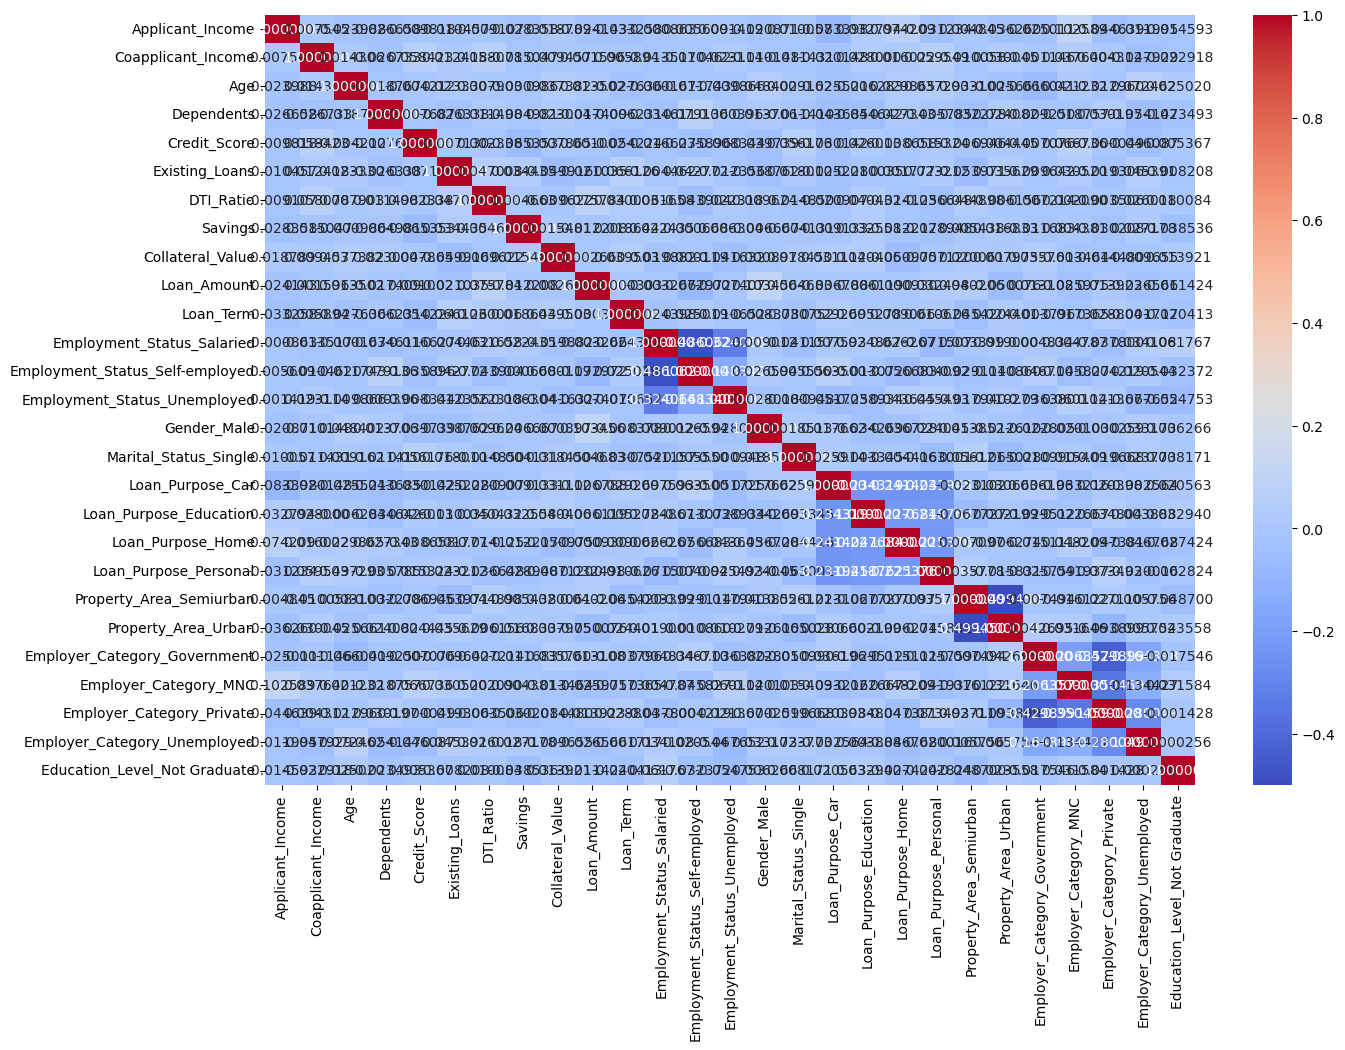

In [48]:
num_cols = df.select_dtypes(include = "number")
corr_matrix = num_cols.corr()
plt.figure(figsize=(15,10))
sns.heatmap(
    corr_matrix,
    annot = True,
    fmt = "2f",
    cmap = "coolwarm"
)

    

In [49]:
corr_matrix

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Education_Level_Not Graduate
Applicant_Income,1.000000,0.007545,-0.023988,-0.026658,-0.009818,-0.010457,-0.009107,-0.028358,0.018789,-0.024143,...,0.032794,0.074209,-0.031234,0.004845,-0.036260,-0.025011,0.102589,-0.044639,-0.011995,-0.014593
Coapplicant_Income,0.007545,1.000000,0.014306,-0.026733,0.058423,0.012418,0.058078,-0.015047,0.009457,0.001596,...,0.028000,0.016022,0.059549,-0.010058,0.030045,-0.001146,0.037640,0.004312,-0.047929,-0.022918
Age,-0.023988,0.014306,1.000000,-0.018767,-0.004212,0.023330,0.007903,-0.000986,0.037382,0.013502,...,-0.006283,0.029865,0.037293,0.003100,-0.025661,-0.066041,0.021232,-0.012960,0.072462,0.025020
Dependents,-0.026658,-0.026733,-0.018767,1.000000,-0.007687,-0.026338,0.011498,-0.004981,0.023004,-0.017409,...,-0.044642,0.027343,-0.005785,-0.032278,0.024082,-0.009250,-0.018757,0.030197,-0.054147,-0.023493
Credit_Score,-0.009818,0.058423,-0.004212,-0.007687,1.000000,-0.007130,0.002338,-0.065353,0.007865,0.001002,...,0.026013,-0.008658,0.015324,-0.006946,0.004445,-0.007076,0.066736,-0.000049,-0.046087,0.005367
Existing_Loans,-0.010457,0.012418,0.023330,-0.026338,-0.007130,1.000000,0.047008,0.034435,-0.049916,-0.021035,...,-0.010035,0.001777,0.023212,-0.053971,0.035629,-0.009642,0.030520,-0.019306,0.045391,-0.008208
DTI_Ratio,-0.009107,0.058078,0.007903,0.011498,0.002338,0.047008,1.000000,0.004663,-0.009622,0.075784,...,0.040432,-0.014125,-0.036648,0.044898,-0.006156,-0.007214,0.002090,-0.003506,0.026018,0.010084
Savings,-0.028358,-0.015047,-0.000986,-0.004981,-0.065353,0.034435,0.004663,1.000000,0.015481,-0.012208,...,0.032558,-0.012217,-0.028948,0.005438,0.016833,-0.011683,0.004381,-0.030208,0.027178,-0.038536
Collateral_Value,0.018789,0.009457,0.037382,0.023004,0.007865,-0.049916,-0.009622,0.015481,1.000000,0.002660,...,0.040406,-0.050975,-0.007120,0.020061,0.007975,0.035760,-0.013464,-0.014480,-0.009655,0.013921
Loan_Amount,-0.024143,0.001596,0.013502,-0.017409,0.001002,-0.021035,0.075784,-0.012208,0.002660,1.000000,...,-0.006119,-0.000930,0.032498,0.040206,-0.050076,0.013108,-0.025975,0.013923,-0.026566,-0.011424


In [50]:
#TRAIN TEST SPLIT
x = df.drop("Loan_Approved", axis=1)
y = df["Loan_Approved"]

In [51]:
x.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Education_Level_Not Graduate
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [52]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [53]:
x_train.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Education_Level_Not Graduate
29,5890.000000,8041.0,31.000000,0.0,603.000000,0.000000,0.11,11906.0,8150.000000,29287.000000,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
535,4779.000000,529.0,50.000000,0.0,614.000000,0.000000,0.21,5369.0,5430.000000,14786.000000,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
695,10852.571579,8927.0,36.000000,0.0,584.000000,4.000000,0.22,3186.0,24802.792632,20522.825263,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
557,2384.000000,2113.0,39.971579,1.0,726.000000,4.000000,0.34,11882.0,48542.000000,13312.000000,...,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
836,5228.000000,5249.0,42.000000,1.0,676.033684,1.950526,0.18,17669.0,24802.792632,13906.000000,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [54]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
                                     


In [55]:
print(x_train.dtypes)

Applicant_Income                   float64
Coapplicant_Income                 float64
Age                                float64
Dependents                         float64
Credit_Score                       float64
Existing_Loans                     float64
DTI_Ratio                          float64
Savings                            float64
Collateral_Value                   float64
Loan_Amount                        float64
Loan_Term                          float64
Employment_Status_Salaried         float64
Employment_Status_Self-employed    float64
Employment_Status_Unemployed       float64
Gender_Male                        float64
Marital_Status_Single              float64
Loan_Purpose_Car                   float64
Loan_Purpose_Education             float64
Loan_Purpose_Home                  float64
Loan_Purpose_Personal              float64
Property_Area_Semiurban            float64
Property_Area_Urban                float64
Employer_Category_Government       float64
Employer_Ca

In [89]:
#TRAIN AND EVAKUATE MODELS
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
log_model = LogisticRegression()
log_model.fit(x_train_scaled, y_train)
y_pred = log_model.predict(x_test_scaled)
print("Logistic_Regression")
print("precision:", precision_score(y_test, y_pred, average = "macro"))
print("confusion_matrix:", confusion_matrix(y_test, y_pred))
print("accuracy_score:", accuracy_score(y_test, y_pred))
print("f1_score:", f1_score(y_test, y_pred, average = "macro"))

Logistic_Regression
precision: 0.8450932684509327
confusion_matrix: [[125  14]
 [ 12  49]]
accuracy_score: 0.87
f1_score: 0.8480598410472183


In [90]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
knn_model = KNeighborsClassifier(n_neighbors = 5)
knn_model.fit(x_train_scaled, y_train)
y_pred = knn_model.predict(x_test_scaled)
print("knn_model")
print("precision:", precision_score(y_test, y_pred, average = "macro"))
print("confusion_matrix:", confusion_matrix(y_test, y_pred))
print("accuracy_score:", accuracy_score(y_test, y_pred))
print("f1_score:", f1_score(y_test, y_pred, average = "macro"))

knn_model
precision: 0.7223490613901573
confusion_matrix: [[119  20]
 [ 27  34]]
accuracy_score: 0.765
f1_score: 0.7131960335621663


In [91]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
nb_model = GaussianNB()
nb_model.fit(x_train_scaled, y_train)
y_pred = nb_model.predict(x_test_scaled)
print("naivebayes_model")
print("precision:", precision_score(y_test, y_pred, average = "macro"))
print("confusion_matrix:", confusion_matrix(y_test, y_pred))
print("accuracy_score:", accuracy_score(y_test, y_pred))
print("f1_score:", f1_score(y_test, y_pred, average = "macro"))

naivebayes_model
precision: 0.8462301587301587
confusion_matrix: [[128  11]
 [ 16  45]]
accuracy_score: 0.865
f1_score: 0.8369122044033706


In [92]:
#feature engineering
#add or transform features
df["DTI_Ratio_sq"] = df["DTI_Ratio"]**2
df["Credit_Score_sq"] = df["Credit_Score"]**2
df["Applicant_Income_log"] = np.log1p(df["Applicant_Income"])
x = df.drop(columns=["Loan_Approved","Credit_Score","DTI_Ratio", "Applicant_Income",])
y = df["Loan_Approved"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

